In [3]:
%cd ..

C:\Users\Barenin Vitalii\PycharmProjects\kaggle-titanic


In [4]:
%load_ext autoreload
%autoreload 2

# %aimport src.config
# %aimport src.data
# %aimport src.features
# %aimport src.feature_search
# %aimport src.openfe_stage
# %aimport src.modeling
# %aimport src.evaluate
# %aimport src.tuning
# %aimport src.tuning_objectives
# %aimport src.logging_utils

import src.config as cfg
import src.data as data
import src.features as features
import src.feature_search as fs
import src.openfe_stage as ofe_stage
import src.modeling as modeling
import src.evaluate as evaluate
import src.tuning as tuning
import src.profiling as prf

from pathlib import Path
import pandas as pd
import joblib

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from pathlib import Path

import joblib
import pandas as pd

from src.config import TARGET_COL, PROCESSED_DATA_DIR, MODELS_DIR
from src.data import load_train, save_processed
# from src.features import TitanicFeatures
# from src.modeling import build_model
# from src.evaluate import cv_scores
from src.logging_utils import log_experiment
from src.feature_search import (
    run_openfe, apply_openfe, save_features,
    feature_importance_report, ablation_openfe
)

In [6]:
def run_experiment(
    model_name: str = "logreg",
    params: dict | None = None,
    run_id: str | None = None,
    save_model: bool = True,
) -> tuple[float, float]:
    """Полный цикл: загрузка → фичи → модель → CV → лог → fit → сохранение."""
    # 1. Загрузка
    df = data.load_train()
    X_raw = df.drop(columns=[cfg.TARGET_COL])
    y = df[cfg.TARGET_COL]

    # 2. Фичи
    fe = features.TitanicFeatures()
    X = fe.transform(X_raw)

    # 3. Модель
    model = modeling.build_model(model_name, X, params=params)

    # 4. CV
    mean, std, scores = evaluate.cv_scores(model, X, y)

    return mean, std

In [7]:
mean, std = run_experiment()

In [8]:
print(f"CV {'logreg'}: mean={mean} std={std}")

CV logreg: mean=0.8249199673592369 std=0.005353041605254536


In [9]:
df = data.load_train()
X_raw = df.drop(columns=[cfg.TARGET_COL])
y = df[cfg.TARGET_COL]

In [10]:
fe = features.TitanicFeatures()
X = fe.transform(X_raw)

In [67]:
df_restored = pd.concat([X, y], axis=1)

In [68]:
dp = prf.DataProfiler(df_restored, target=cfg.TARGET_COL)
print(dp)
# print()
# print("Типы колонок:")
# for col in df.columns:
#     print(f"  {col:12s} → {dp.get_col_type(col)}")
# print()
# print("Пары типов:")
# for c1, c2 in [('Age', cfg.TARGET_COL), ('Sex', cfg.TARGET_COL), ('Age', 'Fare'), ('Sex', 'Embarked')]:
#     print(f"  ({c1}, {c2}) → {dp.get_col_pair_type(c1, c2)}")

DataProfiler(rows=891, cols=8, target='Survived', numeric=5, cat=2)


In [15]:
dp.all_feature_cols

['PassengerId',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [16]:
dp.overview()

,dtype,logical_type,is_target,n_missing,pct_missing,n_unique,pct_unique
column,,,,,,,
PassengerId,int64,numeric,False,0,0.00,891,100.00
Survived,int64,numeric,True,0,0.00,2,0.22
Pclass,int64,numeric,False,0,0.00,3,0.34
Name,str,high_cardinality,False,0,0.00,891,100.00
Sex,str,categorical,False,0,0.00,2,0.22
Age,float64,numeric,False,177,19.87,88,9.88
SibSp,int64,numeric,False,0,0.00,7,0.79
Parch,int64,numeric,False,0,0.00,7,0.79
Ticket,str,high_cardinality,False,0,0.00,681,76.43


In [17]:
dp.info_summary()

{'rows': 891,
 'columns': 12,
 'total_cells': 10692,
 'total_missing': 866,
 'pct_missing': 8.1,
 'duplicated_rows': 0,
 'target': 'Survived',
 'memory_mb': np.float64(0.116),
 'col_types': {'numeric': 7, 'high_cardinality': 3, 'categorical': 2}}

In [20]:
dp.check_duplicates(subset=['Name'])

Дублирующихся строк: 0 (0.0% от 891)
Дубликатов не найдено ✓


""


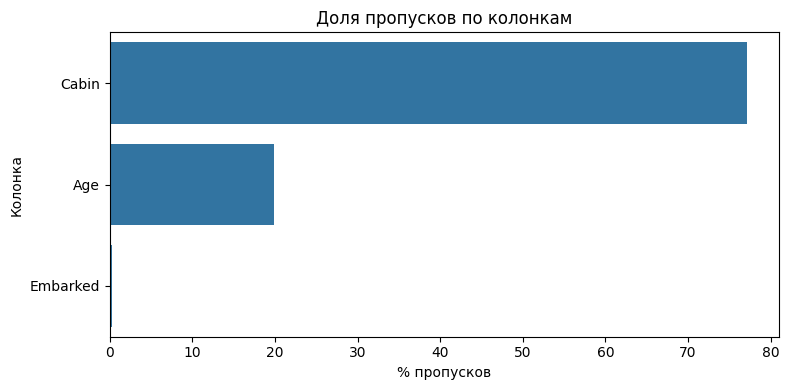

In [21]:
# Таблица по пропускам
dp.missing_summary()

# Топ-10 колонок по % пропусков
dp.plot_missing(top_n=10)

In [23]:
dp.describe_categorical()

,n_unique,top,top_freq,top_pct,missing,pct_missing
column,,,,,,
Name,891,"Braund, Mr. Owen Harris",1,0.11,0,0.00
Ticket,681,347082,7,0.79,0,0.00
Cabin,147,G6,4,1.96,687,77.10
Embarked,3,S,644,72.44,2,0.22
Sex,2,male,577,64.76,0,0.00


In [24]:
dp.describe_numeric()

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,missing,pct_missing
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000,0.000000,-1.200000,0,0.00
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000,-0.630548,-1.280015,0,0.00
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000,0.389108,0.178274,177,19.87
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000,3.695352,17.880420,0,0.00
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000,2.749117,9.778125,0,0.00
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292,4.787317,33.398141,0,0.00
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000,0.478523,-1.775005,0,0.00


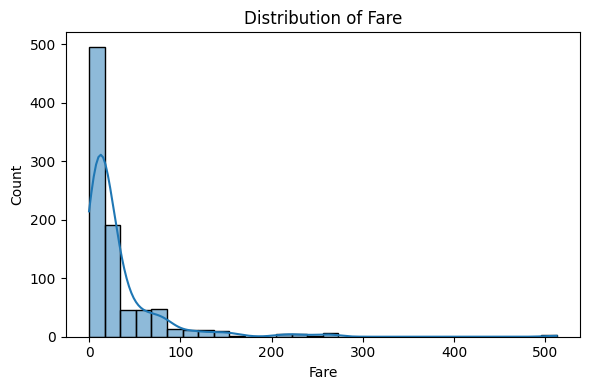

In [60]:
dp.plot_distribution("Fare")        # гистограмма + KDE

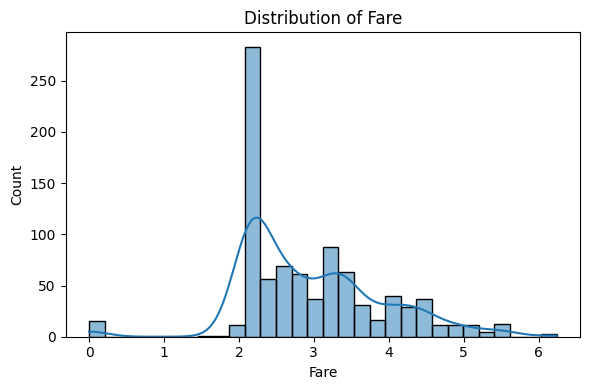

In [69]:
dp.plot_distribution("Fare")   

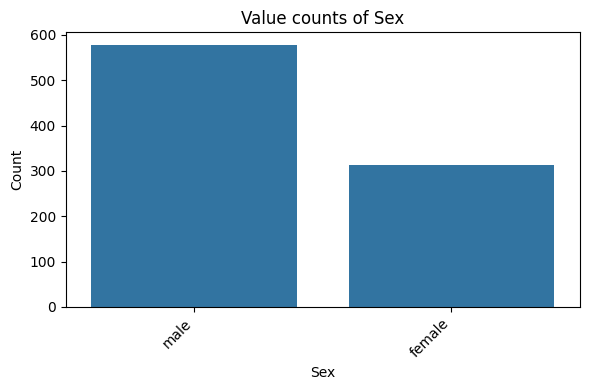

In [26]:
dp.plot_distribution("Sex")        # countplot

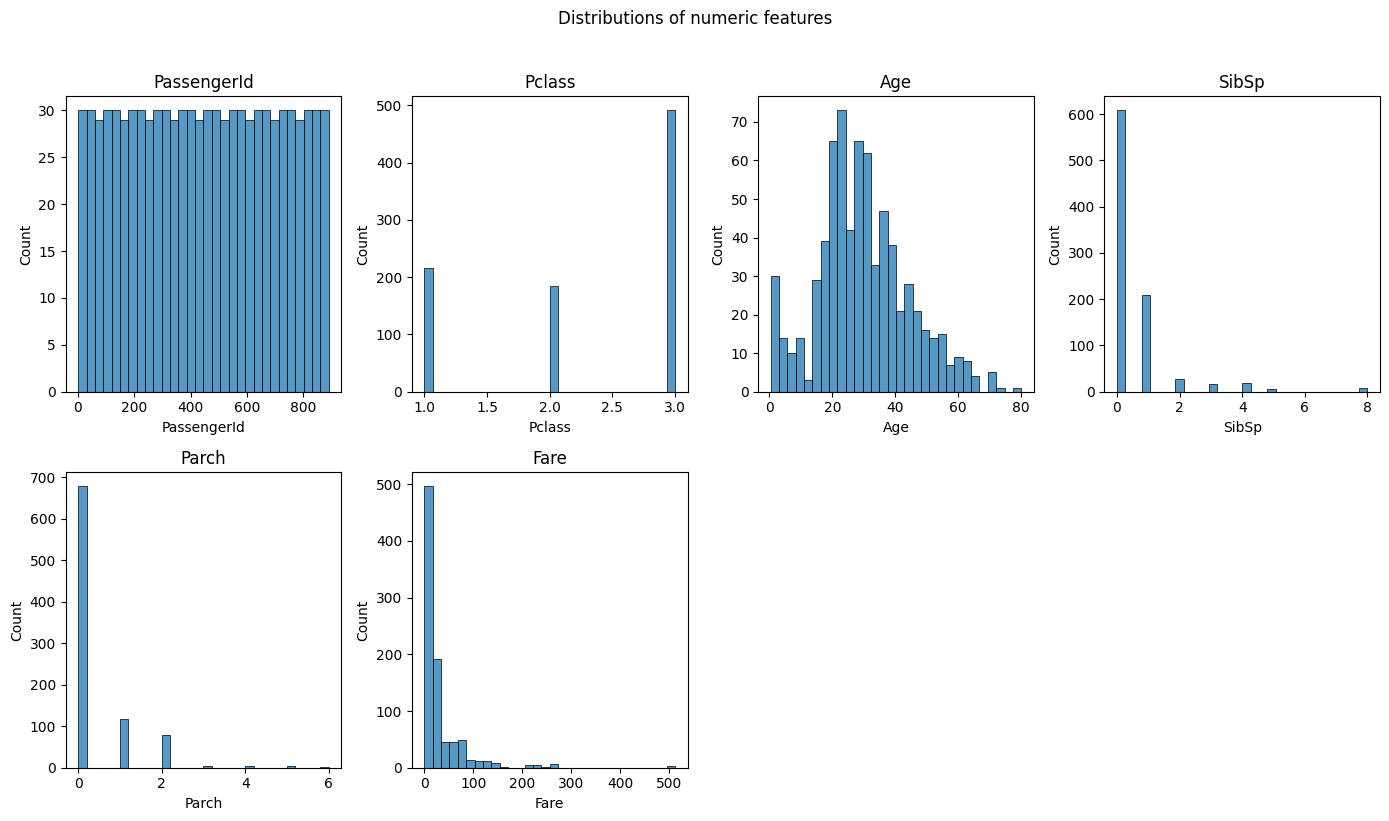

In [28]:
dp.plot_all_distributions(kde=False)        # грид по всем числовым

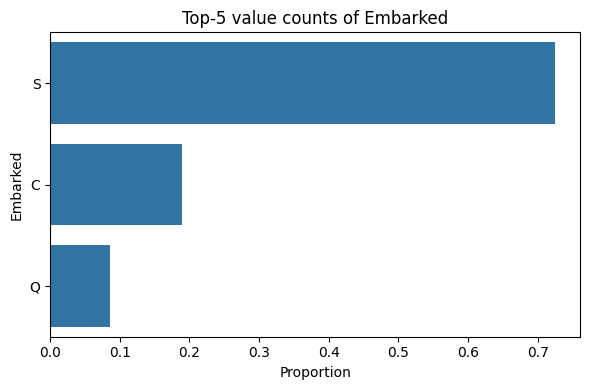

In [32]:
dp.plot_value_counts("Embarked", top_n=5, normalize=True)

In [34]:
dp.detect_outliers_iqr("Fare").sum()
# dp.outliers_summary_iqr("Fare")
# dp.plot_boxplot("Fare")
# dp.plot_boxplot("Fare", by="Survived")
# dp.plot_all_boxplots()

np.int64(116)

In [35]:
# 3. ВРЕМЕННО добавляем target в numeric_cols
original_numeric_cols = dp.numeric_cols.copy()
dp._numeric_cols = original_numeric_cols + ["Survived"]

# 4. Проверяем матрицу корреляций
print(dp.correlation_matrix())


             PassengerId    Pclass       Age     SibSp     Parch      Fare  \
PassengerId     1.000000 -0.035144  0.036847 -0.057527 -0.001652  0.012658   
Pclass         -0.035144  1.000000 -0.369226  0.083081  0.018443 -0.549500   
Age             0.036847 -0.369226  1.000000 -0.308247 -0.189119  0.096067   
SibSp          -0.057527  0.083081 -0.308247  1.000000  0.414838  0.159651   
Parch          -0.001652  0.018443 -0.189119  0.414838  1.000000  0.216225   
Fare            0.012658 -0.549500  0.096067  0.159651  0.216225  1.000000   
Survived       -0.005007 -0.338481 -0.077221 -0.035322  0.081629  0.257307   

             Survived  
PassengerId -0.005007  
Pclass      -0.338481  
Age         -0.077221  
SibSp       -0.035322  
Parch        0.081629  
Fare         0.257307  
Survived     1.000000  


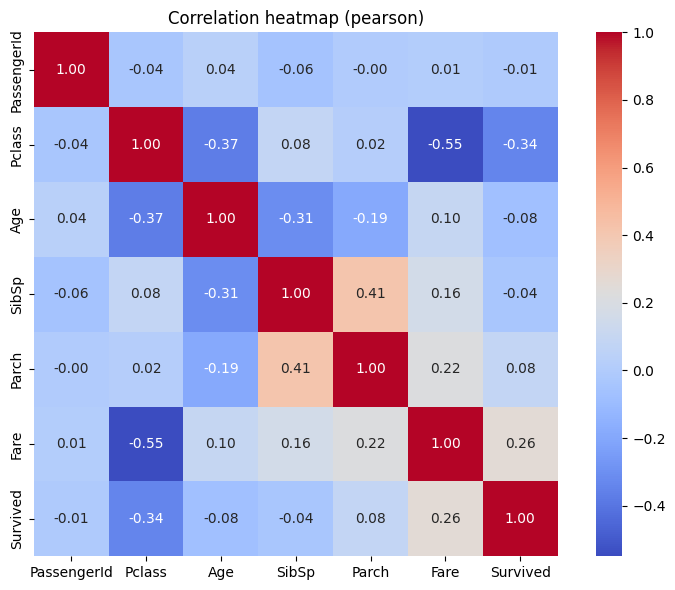

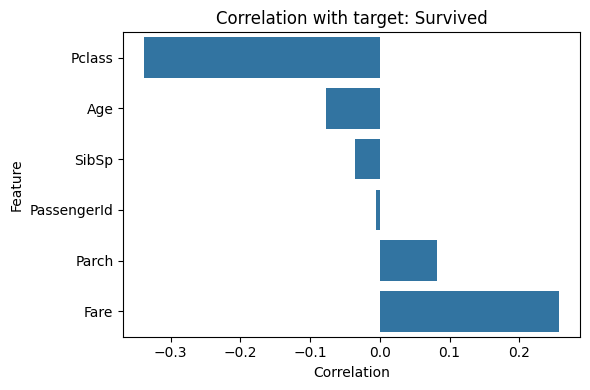

In [36]:
# 5. Проверяем heatmap
dp.plot_corr_heatmap()

# 6. Проверяем корреляцию признаков с target
dp.plot_target_correlation()

# 7. Возвращаем всё как было
dp._numeric_cols = original_numeric_cols

In [ ]:
original_numeric_cols = dp.numeric_cols.copy()
if "Survived" not in dp._numeric_cols:
    dp._numeric_cols = dp._numeric_cols + ["Survived"]

# 1. Бивариантные графики
dp.plot_feature_vs_target("Age")
dp.plot_feature_vs_target("Sex")
dp.plot_feature_vs_target("Fare")
dp.plot_feature_vs_target("Embarked")

# 2. Кросс-таблица и heatmap
print(dp.crosstab("Sex", "Survived"))
dp.plot_crosstab_heatmap("Sex", "Survived")

# 3. Мультиколлинеарность
print(dp.check_multicollinearity(threshold=0.7))

# Возвращаем numeric_cols назад
dp._numeric_cols = original_numeric_cols

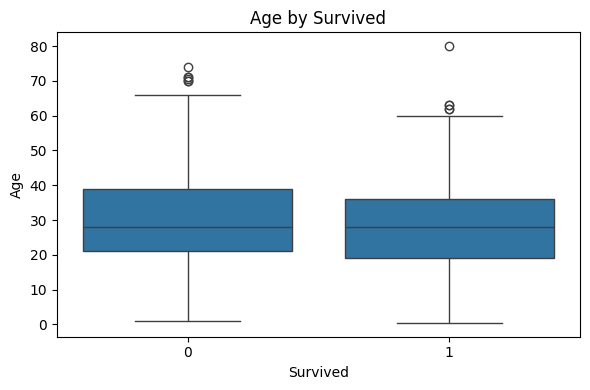

In [46]:
# original_numeric_cols = dp.numeric_cols.copy()
# if "Survived" not in dp._numeric_cols:
#     dp._numeric_cols = dp._numeric_cols + ["Survived"]

# 1. Бивариантные графики
dp.plot_feature_vs_target("Age")

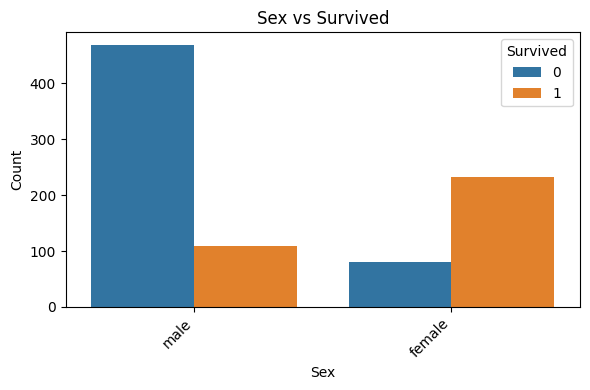

In [45]:
dp.plot_feature_vs_target("Sex")

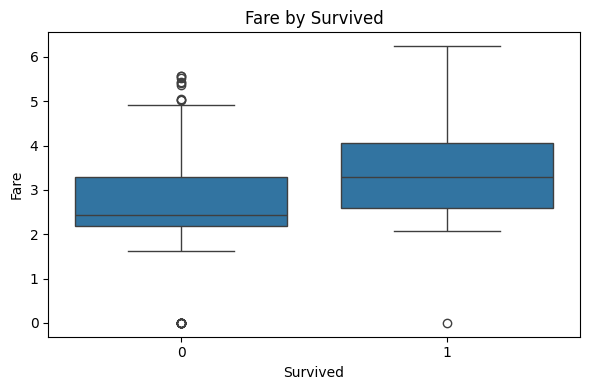

In [70]:
dp.plot_feature_vs_target("Fare")

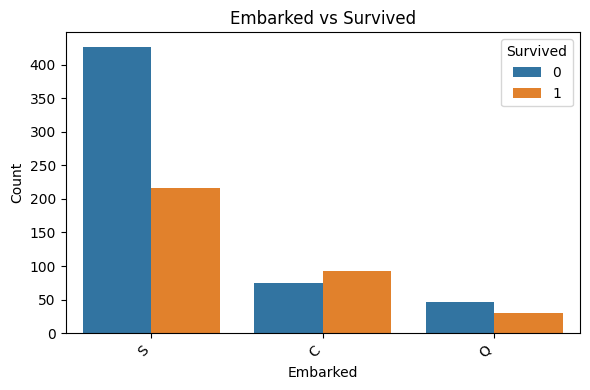

In [48]:
dp.plot_feature_vs_target("Embarked")

In [49]:
print("Embarked:", dp.get_col_type("Embarked"))
print("Survived:", dp.get_col_type("Survived"))
print("pair:", dp.get_col_pair_type("Embarked", "Survived"))

Embarked: categorical
Survived: categorical
pair: ('categorical', 'categorical')


Survived         0         1
Sex                         
female    0.257962  0.742038
male      0.811092  0.188908


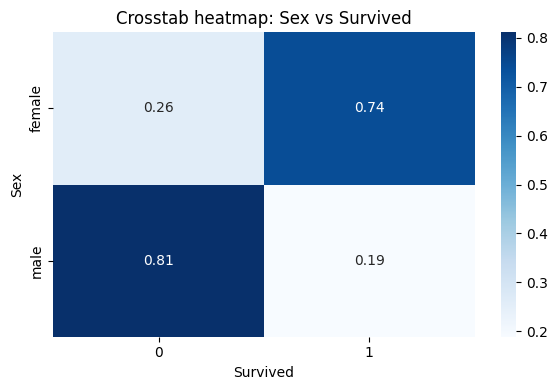

In [50]:
# 2. Кросс-таблица и heatmap
print(dp.crosstab("Sex", "Survived"))
dp.plot_crosstab_heatmap("Sex", "Survived")

In [52]:
print(dp.check_multicollinearity(threshold=0.1))

  feature_1 feature_2  correlation
1    Pclass      Fare      -0.5495
4     SibSp     Parch       0.4148
0    Pclass       Age      -0.3692
2       Age     SibSp      -0.3082
6     Parch      Fare       0.2162
3       Age     Parch      -0.1891
5     SibSp      Fare       0.1597


=== TARGET SUMMARY ===
          count   ratio
Survived               
0           549  0.6162
1           342  0.3838

=== CARDINALITY SUMMARY ===
     column  nunique  n_missing            top_value  top_freq
0      Name      891          0  Abbing, Mr. Anthony         1
1    Ticket      681          0                 1601         7
2     Cabin      147        687              B96 B98         4
3  Embarked        3          2                    S       644
4       Sex        2          0                 male       577

=== CONSTANT COLUMNS ===
[]

=== LOW VARIANCE COLUMNS ===
[]

=== QUASI-CONSTANT COLUMNS ===
['Sex', 'SibSp', 'Parch', 'Cabin', 'Embarked']


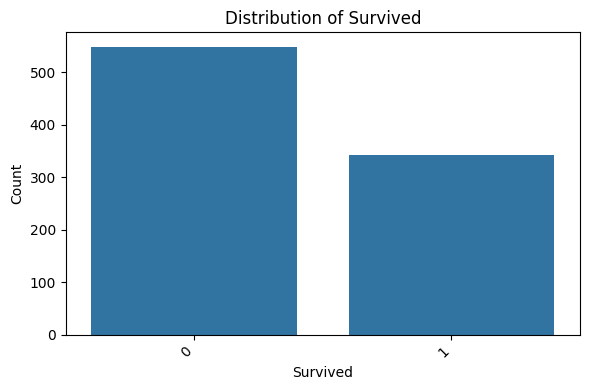

In [55]:
print("=== TARGET SUMMARY ===")
print(dp.target_summary())

print("\n=== CARDINALITY SUMMARY ===")
print(dp.cardinality_summary().head())

print("\n=== CONSTANT COLUMNS ===")
print(dp.constant_columns())

print("\n=== LOW VARIANCE COLUMNS ===")
print(dp.low_variance_columns())

print("\n=== QUASI-CONSTANT COLUMNS ===")
print(dp.quasi_constant_columns(threshold=.60))

dp.plot_target_distribution()

Дублирующихся строк: 0 (0.0% от 891)
Дубликатов не найдено ✓


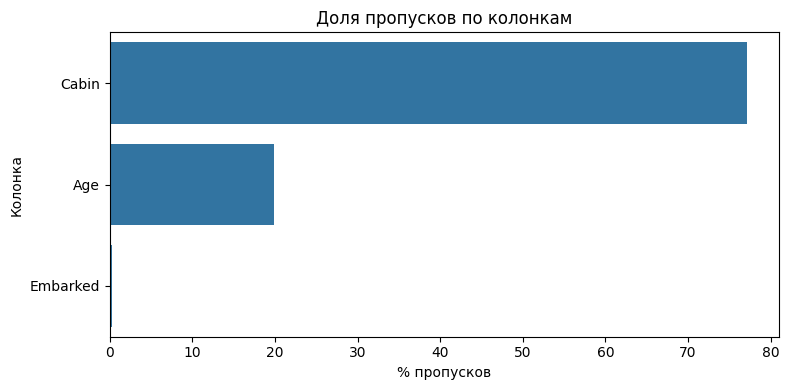

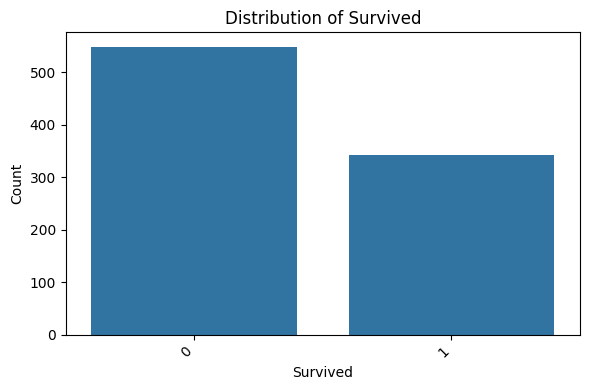

dict_keys(['overview', 'duplicates', 'missing', 'numeric_summary', 'categorical_summary', 'cardinality', 'constant_columns', 'quasi_constant_columns', 'target_summary'])
Дублирующихся строк: 0 (0.0% от 891)
Дубликатов не найдено ✓
dict_keys(['overview', 'duplicates', 'missing_summary', 'numeric_summary', 'categorical_summary', 'cardinality_summary', 'constant_columns', 'quasi_constant_columns', 'low_variance_columns', 'correlation_matrix', 'multicollinearity', 'target_summary', 'target_correlation'])
Дублирующихся строк: 0 (0.0% от 891)
Дубликатов не найдено ✓

==================== OVERVIEW ====================
               dtype      logical_type  is_target  n_missing  pct_missing  \
column                                                                      
PassengerId    int64           numeric      False          0         0.00   
Survived       int64       categorical       True          0         0.00   
Pclass         int64           numeric      False          0         0.00

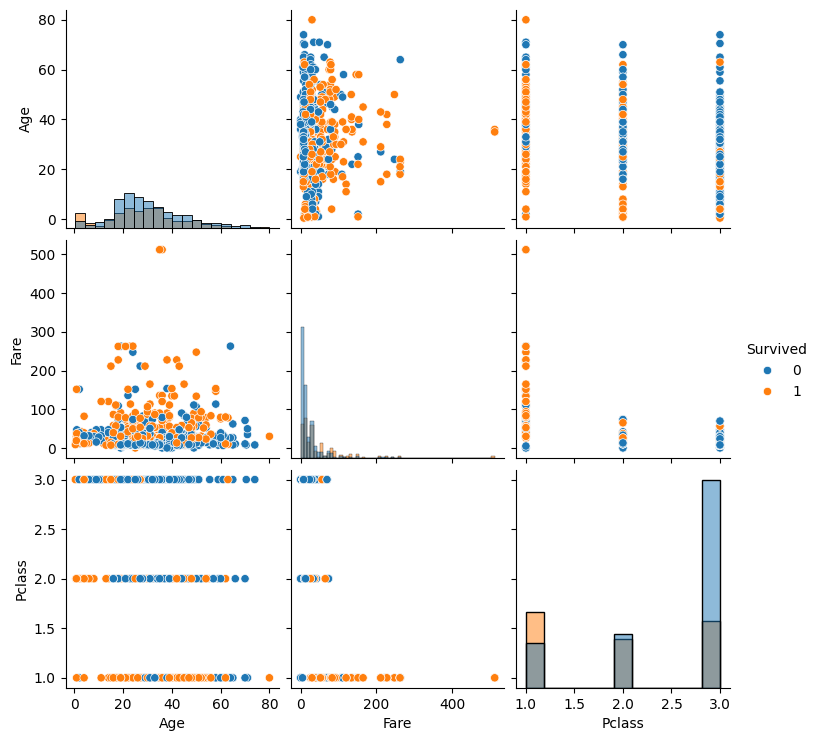

In [56]:
# Если хочешь для корреляции временно учитывать target как numeric:
original_numeric_cols = dp.numeric_cols.copy()
if "Survived" not in dp._numeric_cols:
    dp._numeric_cols = dp._numeric_cols + ["Survived"]

# 1. Быстрый EDA
basic = dp.run_basic_eda(show_plots=True)
print(basic.keys())

# 2. Полный отчёт
report = dp.full_report()
print(report.keys())

# 3. Быстрая печать
dp.print_report()

# 4. Pairplot
dp.plot_pairplot(cols=["Age", "Fare", "Pclass"], hue="Survived")

# вернуть как было
dp._numeric_cols = original_numeric_cols

In [7]:
X.head()

,Pclass,Sex,Age,Fare,Embarked,Title,familysize
0,3,0,22.0,7.2500,S,Mr,2
1,1,1,38.0,71.2833,C,Mrs,2
2,3,1,26.0,7.9250,S,Miss,1
3,1,1,35.0,53.1000,S,Mrs,2
4,3,0,35.0,8.0500,S,Mr,1


In [11]:
from src.openfe_stage import OpenFEStage
from src.config import OPENFE_PARAMS

In [12]:
# ── OpenFEStage: автоматический поиск, отбор, проверка ──────────────────────
stage = OpenFEStage(model_name="logreg", **OPENFE_PARAMS)
X_ofe = stage.fit_transform(X, y)

print("Base columns:    ", stage.base_columns_)
print("Selected OFE:    ", stage.selected_columns_)
print("All output cols: ", stage.get_feature_names_out())

The number of candidate features is 396
Start stage I selection.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.20s/it]


223 same features have been deleted.
Meet early-stopping in successive feature-wise halving.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:07<00:00,  1.84s/it]


The number of remaining candidate features is 163
Start stage II selection.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:03<00:00,  1.02it/s]


Finish data processing.
[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001654 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9851
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 169

── Correlation filter ──
  CORR DROP autoFE_f_5                      |r|=0.9519  (with Pclass)
  CORR DROP autoFE_f_17                     |r|=0.9950  (with Age)
  CORR DROP autoFE_f_18                     |r|=0.9663  (with Fare)
  CORR DROP autoFE_f_19                     |r|=0.9887  (with Fare)

After corr filter: 30 → 26 OFE candidates

── Ablation (batch) ──
  n=  5  mean=0.8249  delta=-0.00000
  n= 10  mean=0.8294  delta=+0.00448
  n= 15  mean=0.8339  delta=+0.00894
  n= 20  mean=0.8384  delta=+0.01344
  n= 25  mean=0.8271  delta=+0.00223

── Greedy selection ──
  KEEP autoFE_f_7                      mean=0.

In [13]:
base_score, base_std, _ = evaluate.cv_scores(modeling.build_model("logreg", X), X, y)
ofe_score, ofe_std, _   = evaluate.cv_scores(modeling.build_model("logreg", X_ofe), X_ofe, y)

print(f"Base:  mean={base_score:.4f}  std={base_std:.4f}")
print(f"+OFE:  mean={ofe_score:.4f}  std={ofe_std:.4f}")
print(f"Delta: {ofe_score - base_score:+.5f}")

Base:  mean=0.8249  std=0.0054
+OFE:  mean=0.8328  std=0.0067
Delta: +0.00785


In [14]:
registry = stage.build_feature_registry(X_ofe)
print(registry.sort_values(["selected", "greedy_delta"], ascending=[False, False]))

       column operator           formula  selected  greedy_mean  greedy_std  \
0  autoFE_f_7        /  (Sex/familysize)      True      0.83277     0.00669   

   greedy_delta  dropped_by_corr corr_with corr_value  
0       0.00785            False      None       None  


In [12]:
if stage.ablation_report_ is not None:
    print(stage.ablation_report_.to_string(index=False))

 n_features     mean      std   delta
          0 0.828291 0.009641 0.00000
          5 0.830544 0.011178 0.00225
         10 0.833890 0.012666 0.00560
         15 0.837254 0.011873 0.00896
         20 0.835013 0.007683 0.00672
         25 0.837261 0.011242 0.00897
         30 0.832766 0.005663 0.00448


In [6]:
model = build_model('logreg', X_raw, params=None)

mean, std, scores = cv_scores(model, X_raw, y)

In [7]:
print(f"CV {'logreg'}: mean={mean} std={std}")

CV logreg: mean=0.8069612704789403 std=0.0332360185803288


In [8]:
fe = TitanicFeatures()
X = fe.transform(X_raw)

# 2. Запуск OpenFE (1-2 минуты)
features = run_openfe(X, y, n_features=30)

# 3. Смотрим что сгенерировано
report = feature_importance_report(features, top_n=20)
print(report.to_string(index=False))

The number of candidate features is 602
Start stage I selection.


100%|██████████| 4/4 [00:12<00:00,  3.01s/it]


343 same features have been deleted.
Meet early-stopping in successive feature-wise halving.


100%|██████████| 4/4 [00:08<00:00,  2.01s/it]


The number of remaining candidate features is 250
Start stage II selection.


100%|██████████| 4/4 [00:04<00:00,  1.19s/it]


Finish data processing.
[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002517 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10470
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 256
 rank        operator feature
    1               - unknown
    2  GroupByThenStd unknown
    3               - unknown
    4 GroupByThenRank unknown
    5 GroupByThenRank unknown
    6               + unknown
    7               / unknown
    8               / unknown
    9               * unknown
   10 GroupByThenRank unknown
   11               + unknown
   12 GroupByThenRank unknown
   13            freq unknown
   14               / unknown
   15 GroupByThenRank unknown
   16 GroupByThenRank unknown
   17  GroupByThenMax unknown
   18 GroupByThenRank unknown
   19  GroupByThenStd unknown
   20  GroupByThenSt

In [9]:
from openfe import transform

# X — это твой текущий X после TitanicFeatures.transform(...)
X_with_ofe, _ = transform(X, X, features, n_jobs=1)  # test можно временно тоже X

base_cols = set(X.columns)
all_cols  = list(X_with_ofe.columns)

new_cols = [c for c in all_cols if c not in base_cols]
print("New OFE features:")
for c in new_cols:
    print(c)

New OFE features:
autoFE_f_0
autoFE_f_1
autoFE_f_2
autoFE_f_3
autoFE_f_4
autoFE_f_5
autoFE_f_6
autoFE_f_7
autoFE_f_8
autoFE_f_9
autoFE_f_10
autoFE_f_11
autoFE_f_12
autoFE_f_13
autoFE_f_14
autoFE_f_15
autoFE_f_16
autoFE_f_17
autoFE_f_18
autoFE_f_19
autoFE_f_20
autoFE_f_21
autoFE_f_22
autoFE_f_23
autoFE_f_24
autoFE_f_25
autoFE_f_26
autoFE_f_27
autoFE_f_28
autoFE_f_29


In [10]:
from openfe import tree_to_formula

mapping = {}
for feat, col in zip(features, new_cols):
    try:
        mapping[col] = tree_to_formula(feat)  # человекочитаемая формула
    except Exception:
        mapping[col] = f"{feat.name}<?>"

In [11]:
for col in new_cols:
    print(col, "→", mapping[col])

autoFE_f_0 → (Sex-autoFE_f_5_manual)
autoFE_f_1 → GroupByThenStd(familysize,Pclass_Sex)
autoFE_f_2 → (Pclass-Pclass_Sex)
autoFE_f_3 → GroupByThenRank(familysize,Title)
autoFE_f_4 → GroupByThenRank(Fare,autoFE_f_5_manual)
autoFE_f_5 → (Age+familysize)
autoFE_f_6 → (Sex/familysize)
autoFE_f_7 → (Fare/familysize)
autoFE_f_8 → (Age*familysize)
autoFE_f_9 → GroupByThenRank(Fare,Pclass)
autoFE_f_10 → (Fare+Age)
autoFE_f_11 → GroupByThenRank(Fare,Age)
autoFE_f_12 → freq(Fare)
autoFE_f_13 → (Fare/Pclass)
autoFE_f_14 → GroupByThenRank(Age,autoFE_f_5_manual)
autoFE_f_15 → GroupByThenRank(Fare,Embarked)
autoFE_f_16 → GroupByThenMax(Fare,familysize)
autoFE_f_17 → GroupByThenRank(Fare,familysize)
autoFE_f_18 → GroupByThenStd(Pclass_Sex,Age)
autoFE_f_19 → GroupByThenStd(autoFE_f_5_manual,Age)
autoFE_f_20 → GroupByThenNUnique(Title,Age)
autoFE_f_21 → GroupByThenStd(Fare,Age)
autoFE_f_22 → GroupByThenRank(Age,Pclass_Sex)
autoFE_f_23 → (Age*autoFE_f_5_manual)
autoFE_f_24 → GroupByThenMean(Fare,familysi

In [12]:
base_score, base_std, _ = cv_scores(build_model("logreg", X), X, y)

In [13]:
results = []

for col in new_cols:
    X_exp = pd.concat([X, X_with_ofe[[col]]], axis=1)
    mean, std, _ = cv_scores(build_model("logreg", X_exp), X_exp, y)
    results.append({
        "col":     col,
        "formula": mapping.get(col, col),
        "mean":    round(mean, 5),
        "std":     round(std, 5),
        "delta":   round(mean - base_score, 5),
    })

df_results = pd.DataFrame(results).sort_values("delta", ascending=False)
print(df_results.to_string(index=False))

        col                                  formula    mean     std    delta
autoFE_f_21                 GroupByThenStd(Fare,Age) 0.83951 0.00442  0.00337
autoFE_f_23                  (Age*autoFE_f_5_manual) 0.83950 0.00930  0.00336
autoFE_f_13                            (Fare/Pclass) 0.83837 0.00682  0.00223
autoFE_f_12                               freq(Fare) 0.83726 0.00616  0.00112
autoFE_f_15           GroupByThenRank(Fare,Embarked) 0.83724 0.01567  0.00110
 autoFE_f_5                         (Age+familysize) 0.83614 0.00427  0.00000
autoFE_f_18           GroupByThenStd(Pclass_Sex,Age) 0.83614 0.00427  0.00000
 autoFE_f_2                      (Pclass-Pclass_Sex) 0.83614 0.00427  0.00000
autoFE_f_27                               (Fare/Sex) 0.83614 0.00427  0.00000
autoFE_f_25 CombineThenFreq(Title,autoFE_f_5_manual) 0.83614 0.00969  0.00000
 autoFE_f_0                  (Sex-autoFE_f_5_manual) 0.83613 0.00674 -0.00001
autoFE_f_17         GroupByThenRank(Fare,familysize) 0.83613 0.0

In [14]:


# Сортированная таблица результатов (уже есть у тебя как df_results)
# Оставляем только те что delta > 0

groups = {
    "delta >= 0.005": df_results[df_results["delta"] >= 0.005]["col"].tolist(),
    "delta >= 0.002": df_results[df_results["delta"] >= 0.002]["col"].tolist(),
    "delta >= 0.001": df_results[df_results["delta"] >= 0.001]["col"].tolist(),
    "delta > 0":      df_results[df_results["delta"] >  0.000]["col"].tolist(),
}

base_score, base_std, _ = cv_scores(build_model("logreg", X), X, y)
print(f"Baseline: {base_score:.5f} ± {base_std:.5f}\n")

rows = [{"threshold": "baseline", "n_features": 0, "mean": base_score, "std": base_std, "delta": 0.0, "cols": []}]

for threshold_name, cols in groups.items():
    X_exp = pd.concat([X, X_with_ofe[cols]], axis=1)
    mean, std, _ = cv_scores(build_model("logreg", X_exp), X_exp, y)
    delta = mean - base_score
    rows.append({
        "threshold":  threshold_name,
        "n_features": len(cols),
        "mean":       round(mean, 5),
        "std":        round(std, 5),
        "delta":      round(delta, 5),
        "cols":       cols,
    })
    print(f"{threshold_name:20s}  n={len(cols):2d}  mean={mean:.5f}  delta={delta:+.5f}")

comparison_df = pd.DataFrame(rows).drop(columns="cols")
print("\n", comparison_df.to_string(index=False))

Baseline: 0.83614 ± 0.00427

delta >= 0.005        n= 0  mean=0.83614  delta=+0.00000
delta >= 0.002        n= 3  mean=0.84062  delta=+0.00448
delta >= 0.001        n= 5  mean=0.83501  delta=-0.00112
delta > 0             n= 5  mean=0.83501  delta=-0.00112

      threshold  n_features     mean      std    delta
      baseline           0 0.836137 0.004268  0.00000
delta >= 0.005           0 0.836140 0.004270  0.00000
delta >= 0.002           3 0.840620 0.007800  0.00448
delta >= 0.001           5 0.835010 0.016920 -0.00112
     delta > 0           5 0.835010 0.016920 -0.00112


In [15]:
sorted_feats = df_results.sort_values("delta", ascending=False)

current_cols = []
current_X = X.copy()
current_score, current_std, _ = cv_scores(build_model("logreg", current_X), current_X, y)
threshold = 0.002

history = []
for _, row in sorted_feats.iterrows():
    col = row["col"]
    cand_X = pd.concat([current_X, X_with_ofe[[col]]], axis=1)
    mean, std, _ = cv_scores(build_model("logreg", cand_X), cand_X, y)
    delta = mean - current_score

    history.append((col, mean, std, delta))

    if delta >= threshold:
        print(f"KEEP {col:10s} mean={mean:.5f} delta={delta:+.5f}")
        current_X = cand_X
        current_cols.append(col)
        current_score = mean
    else:
        print(f"DROP {col:10s} mean={mean:.5f} delta={delta:+.5f}")

print("\nFinal score:", current_score)
print("Selected features:", current_cols)

KEEP autoFE_f_21 mean=0.83951 delta=+0.00337
DROP autoFE_f_23 mean=0.84062 delta=+0.00111
DROP autoFE_f_13 mean=0.84063 delta=+0.00112
DROP autoFE_f_12 mean=0.83727 delta=-0.00224
DROP autoFE_f_15 mean=0.83501 delta=-0.00450
DROP autoFE_f_5 mean=0.83838 delta=-0.00112
DROP autoFE_f_18 mean=0.83614 delta=-0.00336
DROP autoFE_f_2 mean=0.83838 delta=-0.00112
DROP autoFE_f_27 mean=0.83727 delta=-0.00224
DROP autoFE_f_25 mean=0.83950 delta=-0.00001
DROP autoFE_f_0 mean=0.83838 delta=-0.00113
DROP autoFE_f_17 mean=0.83614 delta=-0.00336
DROP autoFE_f_10 mean=0.83614 delta=-0.00336
DROP autoFE_f_3 mean=0.84063 delta=+0.00112
DROP autoFE_f_20 mean=0.83501 delta=-0.00449
DROP autoFE_f_19 mean=0.83502 delta=-0.00449
DROP autoFE_f_7 mean=0.83503 delta=-0.00448
DROP autoFE_f_14 mean=0.83727 delta=-0.00224
DROP autoFE_f_4 mean=0.83500 delta=-0.00451
DROP autoFE_f_9 mean=0.83726 delta=-0.00225
DROP autoFE_f_29 mean=0.83389 delta=-0.00562
DROP autoFE_f_28 mean=0.83614 delta=-0.00337
DROP autoFE_f_22 

In [16]:
current_X.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pclass             891 non-null    int64  
 1   Sex                891 non-null    int64  
 2   Age                714 non-null    float64
 3   Fare               891 non-null    float64
 4   Embarked           889 non-null    str    
 5   Title              891 non-null    str    
 6   familysize         891 non-null    int64  
 7   Pclass_Sex         891 non-null    int64  
 8   autoFE_f_5_manual  889 non-null    float64
 9   autoFE_f_21        714 non-null    float64
dtypes: float64(4), int64(4), str(2)
memory usage: 73.1 KB


In [18]:
mean, std, _ = cv_scores(build_model("logreg", current_X), current_X, y)

In [19]:
print(f"mean={mean} std={std}")

mean=0.8395078777226791 std=0.004417451959921653


In [22]:
for item in history:
    print(item)

('autoFE_f_1', 0.8338899001945892, 0.00464319062602027, 0.0033645094469900716)
('autoFE_f_5', 0.8361308141359614, 0.006739228952984528, 0.002240913941372158)
('autoFE_f_12', 0.8338836231247253, 0.009306238219988322, -0.0022471910112360494)
('autoFE_f_7', 0.8316427091833531, 0.007257861860353865, -0.004488104952608207)
('autoFE_f_15', 0.8305191136777352, 0.0067461711434545595, -0.005611700458226121)
('autoFE_f_6', 0.8327663046889711, 0.00836313501942534, -0.0033645094469902936)
('autoFE_f_9', 0.8361370912058252, 0.007489336174046487, 6.277069863891427e-06)
('autoFE_f_10', 0.8338961772644529, 0.00908946159349088, -0.0022346368715084886)
('autoFE_f_11', 0.8350072186303434, 0.00994161841504319, -0.0011235955056179137)
('autoFE_f_8', 0.8316489862532169, 0.013766331204013917, -0.004481827882744427)
('autoFE_f_18', 0.8338899001945892, 0.010484841410660747, -0.002240913941372158)
('autoFE_f_17', 0.8338899001945892, 0.00464319062602027, -0.002240913941372158)
('autoFE_f_14', 0.8327600276191074,

In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# 1. Базовый список признаков (без autoFE_f_1, autoFE_f_5)
base_features = ["Pclass", "Sex", "Age", "Fare", "Embarked", "Title", "familysize"]

# 2. Добавляем ручной признак Pclass_Sex
current_X["Pclass_Sex"] = current_X["Pclass"] * current_X["Sex"]

# 3. Варианты наборов колонок
feature_sets = {
    "baseline": base_features,
    "baseline + Pclass_Sex": base_features + ["Pclass_Sex"],
    "baseline + Pclass_Sex + autoFE_f_5": base_features + ["Pclass_Sex", "autoFE_f_5"],
    "baseline + autoFE_f_1 + autoFE_f_5": base_features + ["autoFE_f_1", "autoFE_f_5"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, feats in feature_sets.items():
    X_cur = current_X[feats].copy()

    mean, std, _ = cv_scores(build_model("logreg", current_X, params={"max_iter":1000,'C':1.0}), current_X, y)

    print(f"{name}: mean={mean}, std={std}")

baseline: mean=0.836137091205825, std=0.004268038251999833
baseline + Pclass_Sex: mean=0.836137091205825, std=0.004268038251999833
baseline + Pclass_Sex + autoFE_f_5: mean=0.836137091205825, std=0.004268038251999833
baseline + autoFE_f_1 + autoFE_f_5: mean=0.836137091205825, std=0.004268038251999833


In [24]:
mean, std, _ = cv_scores(build_model("logreg", current_X), current_X, y)
print(f"mean={mean} std={std}")

mean=0.8361308141359614 std=0.006739228952984528


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.base import clone
from scipy.stats import loguniform
import numpy as np

def tune_with_random_search(
    base_model,
    X,
    y,
    param_distributions,
    n_iter=30,
    cv=None,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1,
):
    """
    base_model        — Pipeline/модель, уже собранная (prep + clf)
    param_distributions — словарь с распределениями гиперпараметров (для RandomizedSearchCV)
    возвращает: best_model, best_params, search_obj
    """
    if cv is None:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        random_state=random_state,
        verbose=verbose,
        refit=True,  # чтобы сразу обучить лучшую модель на всех данных
    )

    search.fit(X, y)
    best_model = search.best_estimator_
    best_params = search.best_params_
    print(f"RandomizedSearchCV best score: {search.best_score_}")
    print(f"Best params: {best_params}")

    return best_model, best_params, search

In [ ]:
# pipeline = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=1000))])

param_distributions = {
    "model__C": loguniform(1e-3, 1e3),
    "model__solver": ["lbfgs", "liblinear"],
}

best_model_rs, best_params_rs, rs_obj = tune_with_random_search(
    base_model=build_model("logreg", current_X, params={"max_iter":1000,'C':1.0}),
    X=current_X,
    y=y,
    param_distributions=param_distributions,
    n_iter=50,
)

In [13]:
from src.tuning import tune_with_random_search
_, best_params, search = tune_with_random_search("logreg", X_ofe, y)
print(f"RandomizedSearchCV best score: {search.best_score_}")
print(f"Best params: {best_params}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
RandomizedSearchCV best score: 0.835019772770071
Best params: {'model__C': np.float64(0.5450293694558254), 'model__solver': 'lbfgs'}


In [14]:
import importlib
import src.tuning_objectives
import src.tuning

importlib.reload(src.tuning_objectives)
importlib.reload(src.tuning)

<module 'src.tuning' from 'C:\\Users\\Barenin Vitalii\\PycharmProjects\\kaggle-titanic\\src\\tuning.py'>

In [75]:
from src.tuning import tune_with_optuna
best_model, study = tune_with_optuna("logreg", X_ofe, y)
print(f"Optuna best score: {study.best_value}")
print(f"Best params: {study.best_trial.params}")

Optuna best score: 0.8406126420187057
Best params: {'model__C': 3.907967156822881, 'model__solver': 'lbfgs'}


In [47]:
importlib.reload(src.features)
importlib.reload(src.config)
from src.features import TitanicFeatures
from src.modeling import build_model

In [79]:
fe = features.TitanicFeatures()
X = fe.transform(X_raw)
stage = OpenFEStage(model_name="logreg", **OPENFE_PARAMS)
X_ofe = stage.fit_transform(X, y)
model = modeling.build_model('logreg', X_ofe)

mean, std, scores = evaluate.cv_scores(model, X_ofe, y)
print(f"CV {'logreg'}: mean={mean} std={std}")

The number of candidate features is 322
Start stage I selection.


100%|██████████| 4/4 [00:09<00:00,  2.33s/it]


172 same features have been deleted.
Meet early-stopping in successive feature-wise halving.


100%|██████████| 4/4 [00:05<00:00,  1.48s/it]


The number of remaining candidate features is 140
Start stage II selection.


100%|██████████| 4/4 [00:04<00:00,  1.01s/it]


Finish data processing.
[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001301 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6773
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 145

── Correlation filter ──
  CORR DROP autoFE_f_6                      |r|=0.9519  (with Pclass)
  CORR DROP autoFE_f_26                     |r|=0.9950  (with Age)

After corr filter: 30 → 28 OFE candidates

── Ablation (batch) ──
  n=  5  mean=0.8294  delta=+0.00336
  n= 10  mean=0.8294  delta=+0.00335
  n= 15  mean=0.8361  delta=+0.01007
  n= 20  mean=0.8305  delta=+0.00448
  n= 25  mean=0.8395  delta=+0.01347

── Greedy selection ──
  KEEP autoFE_f_7                      mean=0.83164  delta=+0.00560
  DROP autoFE_f_10                     mean=0.83053  delta=-0.00111
  KEEP autoFE_f_13                     mean=0.

In [21]:
current_X.head()

,Pclass,Sex,Age,Fare,Embarked,Title,familysize,Pclass_Sex,autoFE_f_5_manual,autoFE_f_21
openfe_index,,,,,,,,,,
0,3,0,22.0,7.2500,S,Mr,2,0,0.726708,37.655129
1,1,1,38.0,71.2833,C,Mrs,2,1,0.255952,70.996756
2,3,1,26.0,7.9250,S,Miss,1,3,0.726708,19.057277
3,1,1,35.0,53.1000,S,Mrs,2,1,0.099379,155.599330
4,3,0,35.0,8.0500,S,Mr,1,0,0.726708,155.599330


In [50]:
X.head()

,Pclass,Sex,Age,Fare,Embarked,Title,familysize,Pclass_Sex,autoFE_f_21_manual
0,3,0,22.0,7.2500,S,Mr,2,0,38.015474
1,1,1,38.0,71.2833,C,Mrs,2,1,72.750026
2,3,1,26.0,7.9250,S,Miss,1,3,19.335500
3,1,1,35.0,53.1000,S,Mrs,2,1,157.870974
4,3,0,35.0,8.0500,S,Mr,1,0,157.870974


In [77]:
X_ofe[X_ofe.select_dtypes(include="number").columns].corr()

,Pclass,Sex,Age,Fare,familysize,autoFE_f_7,autoFE_f_13,autoFE_f_20,autoFE_f_23,autoFE_f_2,autoFE_f_3
Pclass,1.000000,-0.131900,-0.369226,-0.661022,0.065997,-0.601542,0.605551,0.447533,0.585776,-0.088326,0.843338
Sex,-0.131900,1.000000,-0.093254,0.263276,0.200988,0.210818,-0.590570,-0.196168,-0.173043,0.885819,0.001568
Age,-0.369226,-0.093254,1.000000,0.116495,-0.301914,0.029967,-0.022275,0.601746,-0.200689,-0.280180,-0.406745
Fare,-0.661022,0.263276,0.116495,1.000000,0.383658,0.796014,-0.499105,-0.465558,-0.348950,0.298540,-0.302353
familysize,0.065997,0.200988,-0.301914,0.383658,1.000000,0.342273,-0.261509,-0.273152,0.117154,0.362300,0.314010
autoFE_f_7,-0.601542,0.210818,0.029967,0.796014,0.342273,1.000000,-0.487497,-0.430349,-0.436966,0.250081,-0.334892
autoFE_f_13,0.605551,-0.590570,-0.022275,-0.499105,-0.261509,-0.487497,1.000000,0.478220,0.471231,-0.677094,0.326765
autoFE_f_20,0.447533,-0.196168,0.601746,-0.465558,-0.273152,-0.430349,0.478220,1.000000,0.363154,-0.342726,0.292774
autoFE_f_23,0.585776,-0.173043,-0.200689,-0.348950,0.117154,-0.436966,0.471231,0.363154,1.000000,-0.144042,0.479378
autoFE_f_2,-0.088326,0.885819,-0.280180,0.298540,0.362300,0.250081,-0.677094,-0.342726,-0.144042,1.000000,0.088206
